In [1]:
### Please check _common.py for common paths and loaded packages 
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Read data

In [2]:
### Hurricane track ###
# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')

# Interpolation function for TC track
f_loc, t0 = tc_func.get_interp_func(tc_info)


### Select ASOS data ###
asos_data, _ = tc_func.read_ASOS_data(os.path.join(data_dir, 'ASOS/645A_HUM.csv'))

# Select time range
t1, t2 = UTCDateTime(2012, 8, 27), UTCDateTime(2012, 9, 1)
_tmask = ((asos_data['time'] >= pd.Timestamp(t1.datetime)) \
          & (asos_data['time'] <= pd.Timestamp(t2.datetime))) \
          & (asos_data['wind'] > 0)
asos_val = asos_data[_tmask]

# Read ASOS station metadata
csv_files = [os.path.join(data_dir, 'ASOS/LA_meta.csv')]
asos_info = read_asos_metadata(csv_files)
asos_sta_loc = np.array([get_asos_sta_loc('HUM', asos_info)])[0]


### Wind spectra & structure function ###
_dir = os.path.join(data_dir, 'fcmp_tower/turbulence')

U_tower = np.load(os.path.join(_dir, f'Suu_10m.npz'), allow_pickle=True)
Suu = np.load(os.path.join(_dir, f'Suu_15m.npz'), allow_pickle=True)
Duu = np.load(os.path.join(_dir, f'Duu_15m.npz'), allow_pickle=True)


### Pressure spectra & structure function ###
_dir = os.path.join(data_dir, 'TA/turbulence')

stnm = '645A'
Cpp = np.load(os.path.join(_dir, f'Cpp_{stnm}.npz'), allow_pickle=True)
Dpp = np.load(os.path.join(_dir, f'Dpp_{stnm}.npz'), allow_pickle=True)

# TA station location
sta_info = pd.read_csv('../Data/TA/TA_list.csv')
seis_sta_loc = np.array([get_sta_loc(['TA', stnm], sta_info)])[0]

# Time axis for infrasound data
t_prs = np.array([Cpp['t0'][0] + pd.Timedelta(hours=h) for h in Cpp['t_hr']])
t_prs_mpl = np.array([obj.matplotlib_date for obj in t_prs])


## Wind speed and pressure

In [3]:
### Wind model ###

def wind_model(Rm, Vm, b):
    
    # Parameter solved by forcing the maximum value to Vm
    # Eqn. (1)
    a = Rm**(2-b) / (b-1)
    C = b / (b-1) / 2

    # Return function handles
    # Eqns (1) & (2)
    wind_m = lambda r: r*(2*Rm*Vm) / (Rm**2 + a*(r**b)) * C   
    return wind_m


# TA station distance to hurricane center
_, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_list=t_prs)
tc_dist = tc_func.get_station_dist(seis_sta_loc, np.array([tc_lon, tc_lat]))
imin = np.argmin(tc_dist)

wm1 = wind_model(Rm=60, Vm=17, b=2.0)
wm2 = wind_model(Rm=55, Vm=15, b=1.7)
ws_model = np.zeros_like(tc_dist)
ws_model[:imin] = wm1(tc_dist[:imin])
ws_model[imin:] = wm2(tc_dist[imin:])

ERA5: Single level


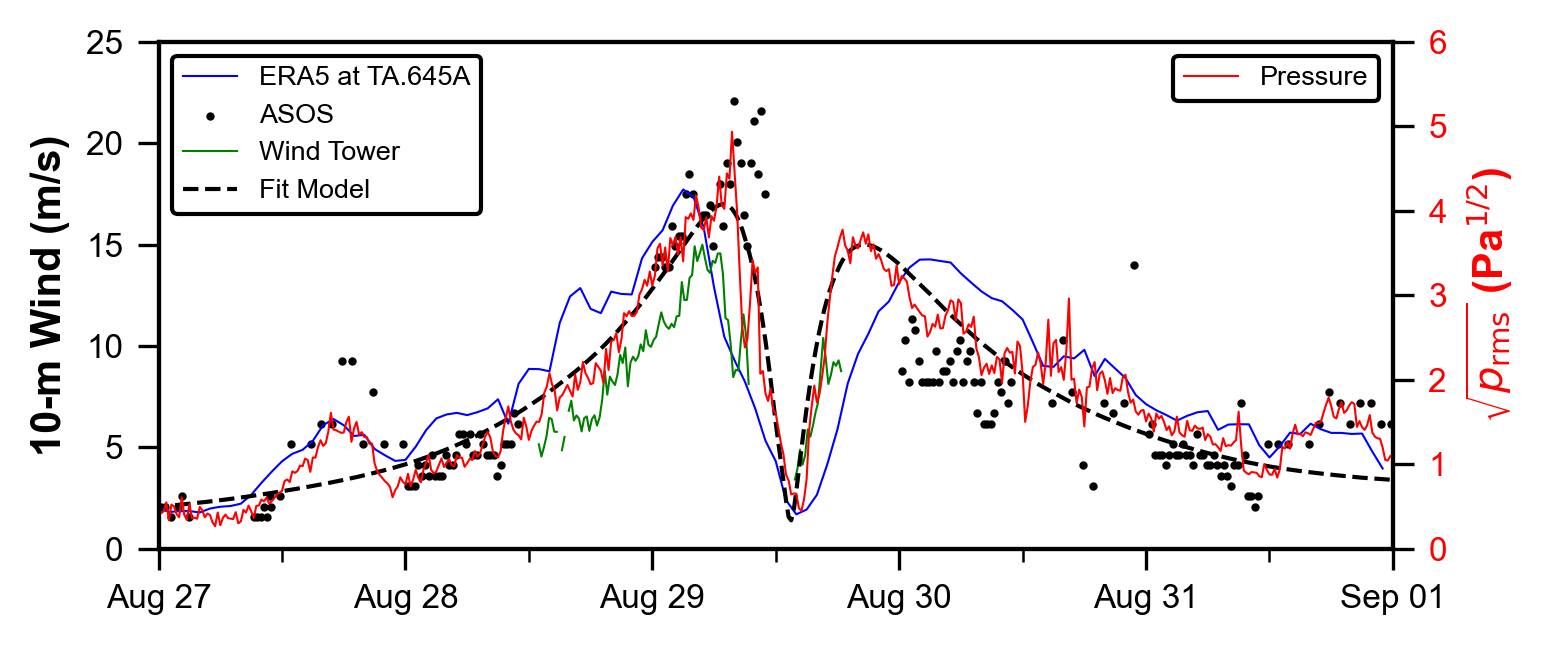

In [4]:
### Plot wind speed and pressure amplitude ###

# ERA5 at seismic station
era5_dir = os.path.join(data_dir, 'Isaac/ERA5')
era5_file = os.path.join(era5_dir, 'data_stream-oper.nc')
era5_slev_data = atm_ds.read_era5(era5_file);

# Interpolated at stations: Single level
era5_slev_seis = era5_slev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0])
era5_slev_seis['wspd'] = np.sqrt(era5_slev_seis['u10']**2 + era5_slev_seis['v10']**2)

# Find gap in wind tower data
breaks = np.where(np.diff(U_tower['time']) > timedelta(minutes=20))[0] + 1
seg_t = np.split(U_tower['time'], breaks)
seg_U = np.split(U_tower['U'], breaks)

# Plot wind speed
fig, ax = plt.subplots(figsize=(5.25, 2.25))
ax.plot(era5_slev_seis['valid_time'], era5_slev_seis['wspd'].values, 'b-', lw=0.5, label='ERA5 at TA.645A')
ax.scatter(asos_val['time'], asos_val['wind'], s=1, marker='o', color='k', label='ASOS')
ax.plot(seg_t[0], seg_U[0], 'g', lw=0.5, label='Wind Tower')
for tseg, useg in zip(seg_t[1:], seg_U[1:]):
    ax.plot(tseg, useg, 'g', lw=0.5)
ax.plot(t_prs, ws_model, 'k--', lw=1, label='Fit Model')
ax.set_ylabel('10-m Wind (m/s)')

# Plot pressure amplitude
ax2 = ax.twinx()
ax2.plot(t_prs_mpl, np.sqrt(Cpp['p_rms']), lw=0.5, color='r', label='Pressure')
ax2.set_ylabel(r'$\sqrt{p_{\mathrm{rms}}}$ (Pa$^{1/2}$)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax.legend(fontsize=6.5, loc='upper left')
ax2.legend(fontsize=6.5, loc='upper right')
# ax.set_title('Station: ' + stnm)

ax.set_xlim([t1, t2])
ax.set_ylim([0, 25])
ax2.set_ylim([0, 6])
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
# fig.savefig(os.path.join(fig_dir, 'wind_speed.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Wind spectra

In [5]:
### Inertial subrange ###

# Wind spectra
def model_log_u(f, log_eps, U, expo=5/3, alpha=0.5):
    return np.log(alpha) + (2/3)*log_eps + (2/3)*np.log(U/(2*np.pi)) - expo*np.log(f)

# Structure function
def modelD_log_u(tau, log_eps, U, expo=2/3, C=2.01):
    return np.log(C) + (2/3)*log_eps + (2/3)*np.log(U) + expo*np.log(tau)

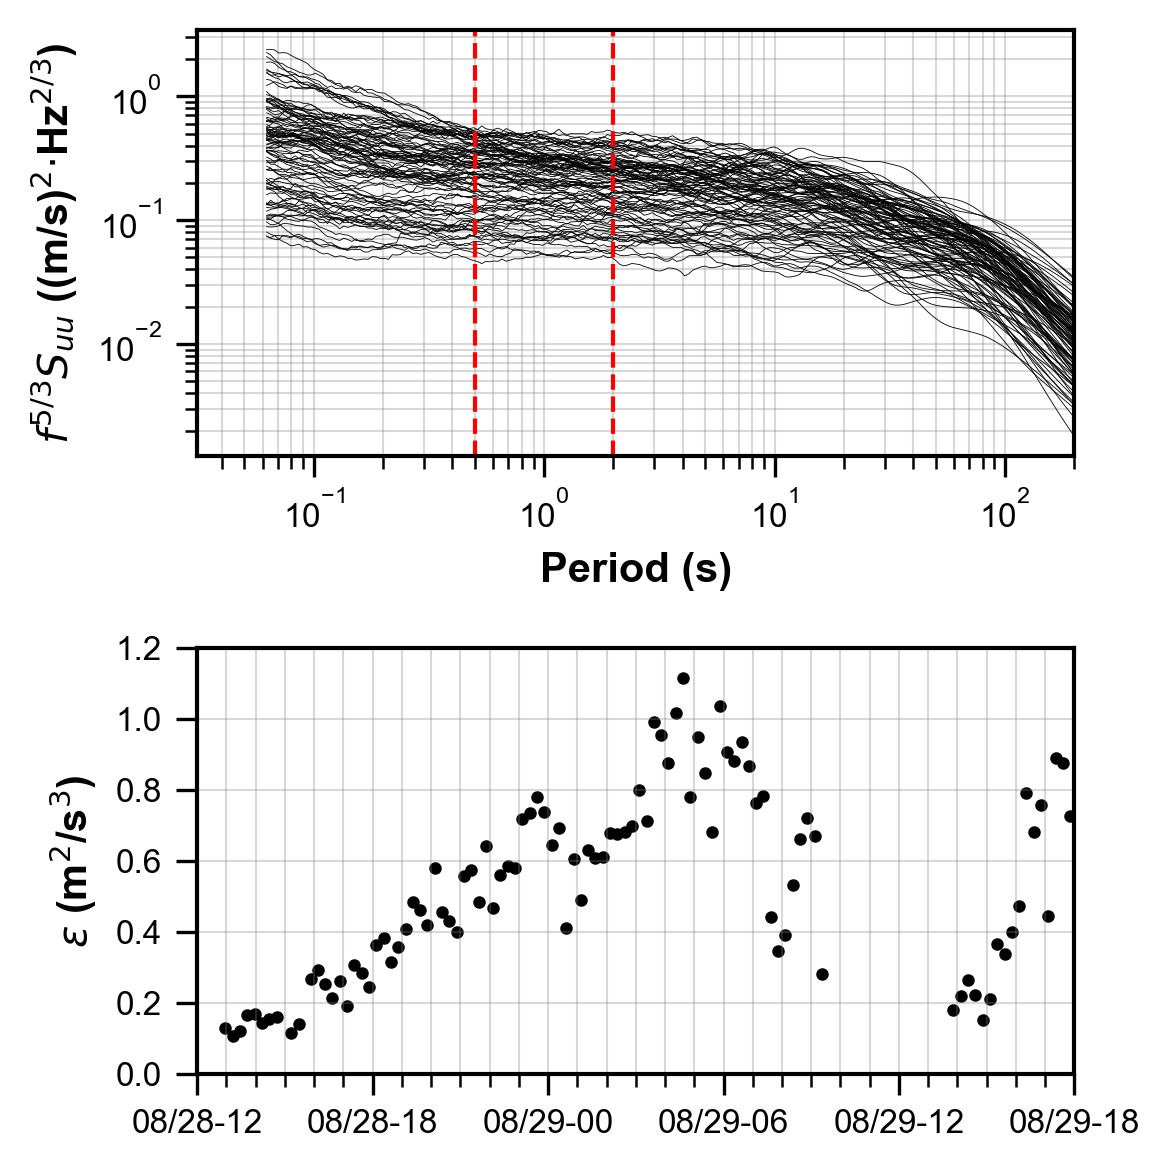

In [7]:
### Inertial subrange: Wind spectra ###

# Inertial subrange
Ti_min, Ti_max = 0.5, 2

freqs = Suu['freqs_sm']
epsilon_u = []
sigma_eps_u = []

fig, axes = plt.subplots(2, 1, figsize=(4, 4))
for i in range(len(Suu['time'])):
    Suu_ = Suu['Suu_sm'][i]
    Umean = Suu['U'][i]
    axes[0].loglog(1/freqs, Suu_*freqs**(5/3), 'k-', lw=0.2)

    # Restrict to inertial subrange
    mask = (freqs >= 1/Ti_max) & (freqs <= 1/Ti_min)
    f_fit, S_fit = freqs[mask], 2*Suu_[mask]         # PSD to one-sided

    # Estimate dissipation rate
    popt, pcov = curve_fit(lambda f, log_eps: model_log_u(f, log_eps, Umean), f_fit, np.log(S_fit), p0=[-1])
    epsilon_u.append(np.exp(popt[0]))

    # Uncertainty estimation
    I = (Suu_*freqs**(5/3))[mask]
    sigma_eps_u.append(1.5 * np.std(I) / np.mean(I))

epsilon_u = np.array(epsilon_u)
sigma_eps_u = np.array(sigma_eps_u)

axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel(r'$f^{5/3}S_{uu}$ ((m/s)$^2$$\cdot$Hz$^{2/3}$)')
# axes[0].set_ylabel(r'$S_{uu}$ ((m/s)$^2$/Hz)')
axes[0].set_xlim([1/32, 200])
axes[0].axvline(x=Ti_min, color='r', ls='--', lw=1)
axes[0].axvline(x=Ti_max, color='r', ls='--', lw=1)
axes[1].scatter(Suu['time'], epsilon_u, c='k', marker='.')
axes[1].set_ylim([0, 1.2])
axes[1].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$)')
axes[1].set_xlim([datetime(2012,8,28,12), datetime(2012,8,29,18)])

# Date ticks
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=range(0,24,6)))
axes[1].xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0,24,1)))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d-%H'))

for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.3)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'Suu.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

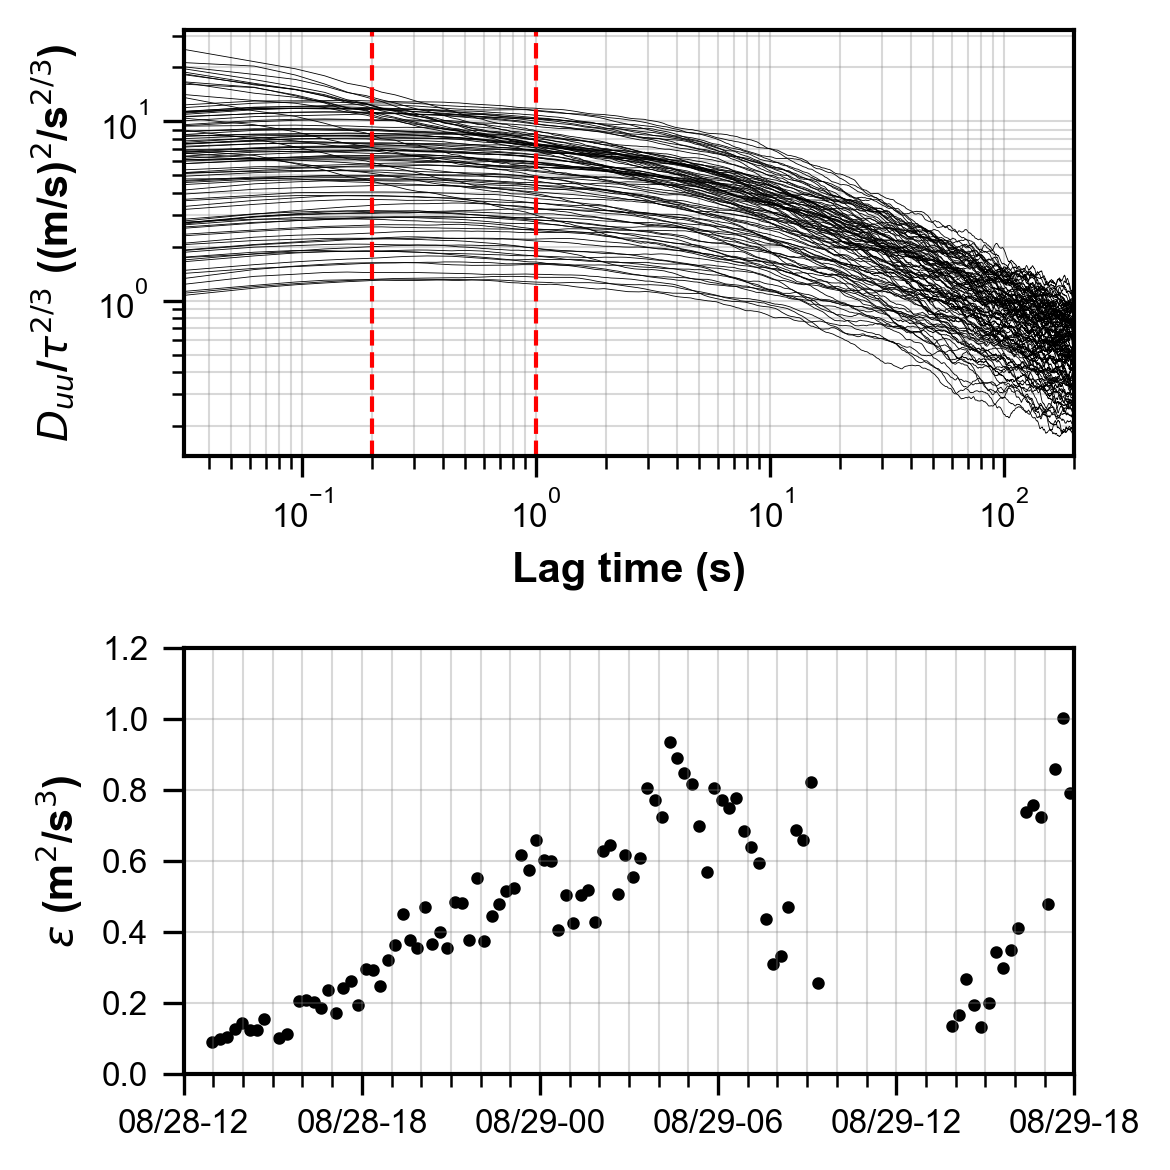

In [8]:
### Inertial subrange: Wind structure function ###

# Inertial subrange
tau_min, tau_max = 0.2, 1

tau = Duu['tau']
epsilonD_u = []
sigma_epsD_u = []

fig, axes = plt.subplots(2, 1, figsize=(4, 4))
for i in range(len(Duu['time'])):
    D11 = Duu['Duu'][i]
    Umean = Duu['U'][i]
    axes[0].loglog(tau, D11/tau**(2/3), 'k-', lw=0.2)

    # Restrict to inertial subrange
    mask = (tau >= tau_min) & (tau <= tau_max)
    tau_fit, D11_fit = tau[mask], D11[mask]

    # Estimate dissipation rate
    popt, pcov = curve_fit(lambda f, log_eps: modelD_log_u(f, log_eps, Umean), tau_fit, np.log(D11_fit), p0=[-1])
    epsilonD_u.append(np.exp(popt[0]))

    # Uncertainty estimation
    I = (D11/tau**(2/3))[mask]
    sigma_epsD_u.append(1.5 * np.std(I) / np.mean(I))

epsilonD_u = np.array(epsilonD_u)
sigma_epsD_u = np.array(sigma_epsD_u)

axes[0].set_xlabel('Lag time (s)')
axes[0].set_ylabel(r'$D_{uu}$/$\tau^{2/3}$ ((m/s)$^2$/s$^{2/3}$)')
# axes[0].set_ylabel(r'$D_{uu}$ ((m/s)$^2$)')
axes[0].set_xlim([1/32, 200])
axes[0].axvline(x=tau_min, color='r', ls='--', lw=1)
axes[0].axvline(x=tau_max, color='r', ls='--', lw=1)
axes[1].scatter(Duu['time'], epsilonD_u, c='k', marker='.')
axes[1].set_ylim([0, 1.2])
axes[1].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$)')
axes[1].set_xlim([datetime(2012,8,28,12), datetime(2012,8,29,18)])

# Date ticks
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=range(0,24,6)))
axes[1].xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0,24,1)))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d-%H'))

for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.3)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'Duu.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Pressure spectra

In [9]:
### Inertial subrange ###

# Turbulence-turbulence pressure spectra
def model_log_p(f, log_eps, U, expo=7/3, C=1.27, rho=1.11):
    return np.log(C) + 2*np.log(rho) + (4/3)*log_eps + (4/3)*np.log(U/(2*np.pi)) - expo*np.log(f)

# Structure function
def modelD_log_p(tau, log_eps, U, expo=4/3, Cp=3.87, rho=1.11):
    return np.log(Cp) + 2*np.log(rho) + (4/3)*log_eps + (4/3)*np.log(U) + expo*np.log(tau)

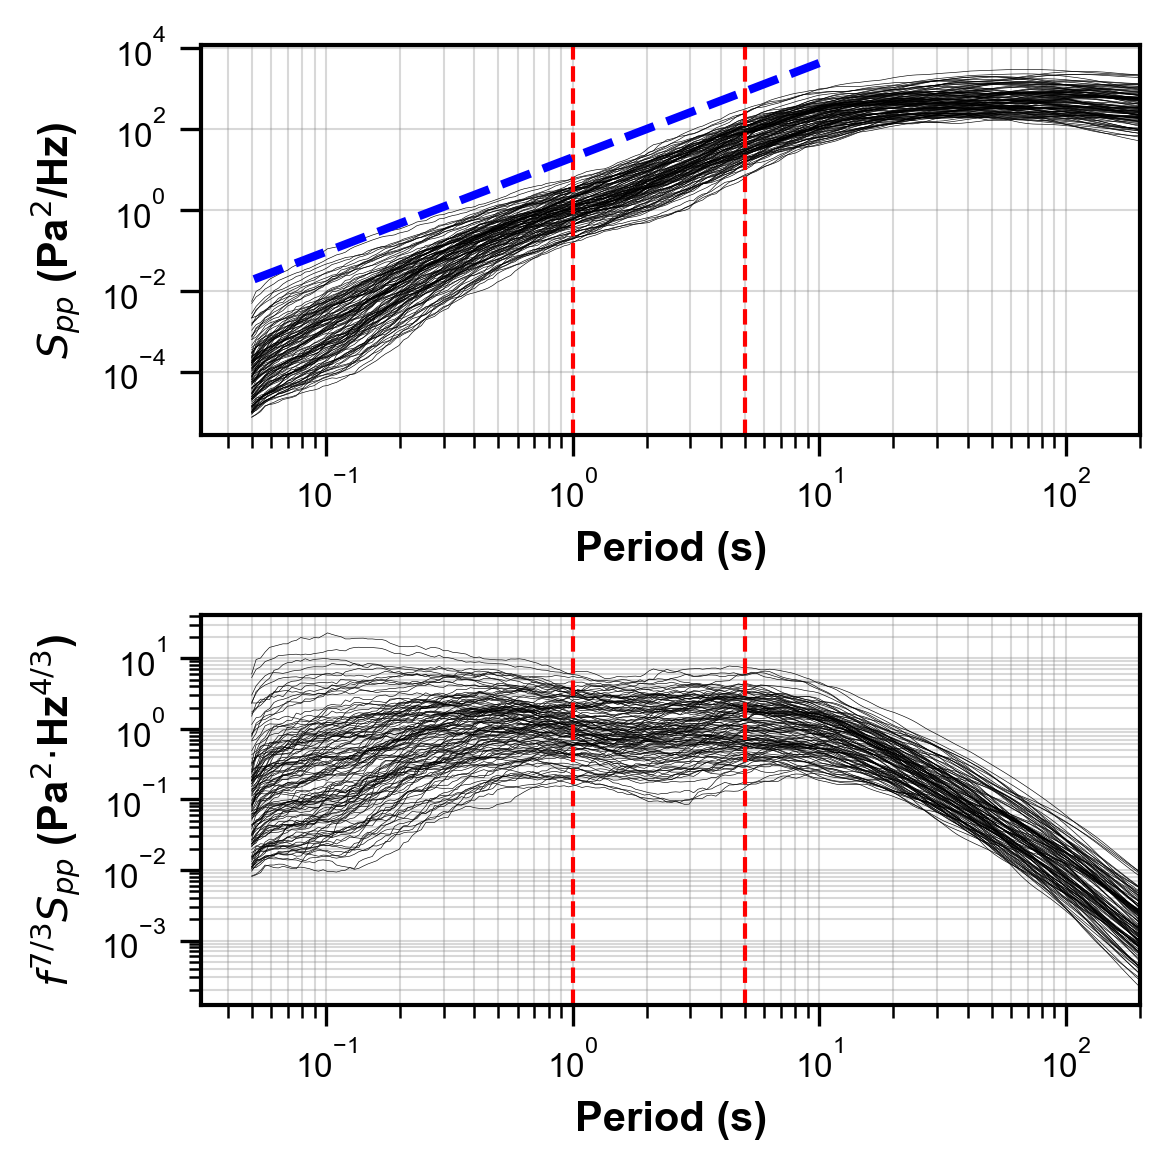

In [10]:
### Inertial subrange: Pressure spectra ###

# Inertial subrange
Ti_min, Ti_max = 1, 5

# Advecive velocity / U10
U_fac = 1.8

freqs = Cpp['freqs_sm']
epsilon_p = []
sigma_eps_p = []

fig, axes = plt.subplots(2, 1, figsize=(4, 4))
for i in range(len(Cpp['t_hr'])):
    Cpp_ = Cpp['Cpp_sm'][i]
    # U10 = ws_model[i]
    U10 = np.sqrt(Cpp['p_rms'][i])/6*25
    Uc = U10 * U_fac
    if U10 > 10:
        axes[0].loglog(1/freqs, Cpp_, 'k-', lw=0.15)
        axes[1].loglog(1/freqs, Cpp_*freqs**(7/3), 'k-', lw=0.15)

    # Restrict to inertial subrange
    mask = (freqs >= 1/Ti_max) & (freqs <= 1/Ti_min)
    f_fit, S_fit = freqs[mask], 2*Cpp_[mask]         # PSD to one-sided

    # Estimate dissipation rate
    popt, pcov = curve_fit(lambda f, log_eps: model_log_p(f, log_eps, Uc), f_fit, np.log(S_fit), p0=[1e-1])
    epsilon_p.append(np.exp(popt[0]))

    # Uncertainty estimation
    I = (Cpp_*freqs**(7/3))[mask]
    sigma_eps_p.append(0.75 * np.std(I) / np.mean(I))

epsilon_p = np.array(epsilon_p)
sigma_eps_p = np.array(sigma_eps_p)

axes[0].set_xlabel('Period (s)')
axes[0].set_ylabel(r'$S_{pp}$ (Pa$^2$/Hz)')
axes[0].set_xlim([1/32, 200])
axes[0].axvline(x=Ti_min, color='r', ls='--', lw=1)
axes[0].axvline(x=Ti_max, color='r', ls='--', lw=1)
axes[1].set_xlabel('Period (s)')
axes[1].set_ylabel(r'$f^{7/3}S_{pp}$ (Pa$^2$$\cdot$Hz$^{4/3}$)')
axes[1].set_xlim([1/32, 200])
axes[1].axvline(x=Ti_min, color='r', ls='--', lw=1)
axes[1].axvline(x=Ti_max, color='r', ls='--', lw=1)

# Reference scaling
f_ = np.linspace(1e-1, 20, 100)
axes[0].loglog(1/f_, 2e1*f_**(-7/3), 'b--', lw=2.0)

for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.3)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'Spp.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

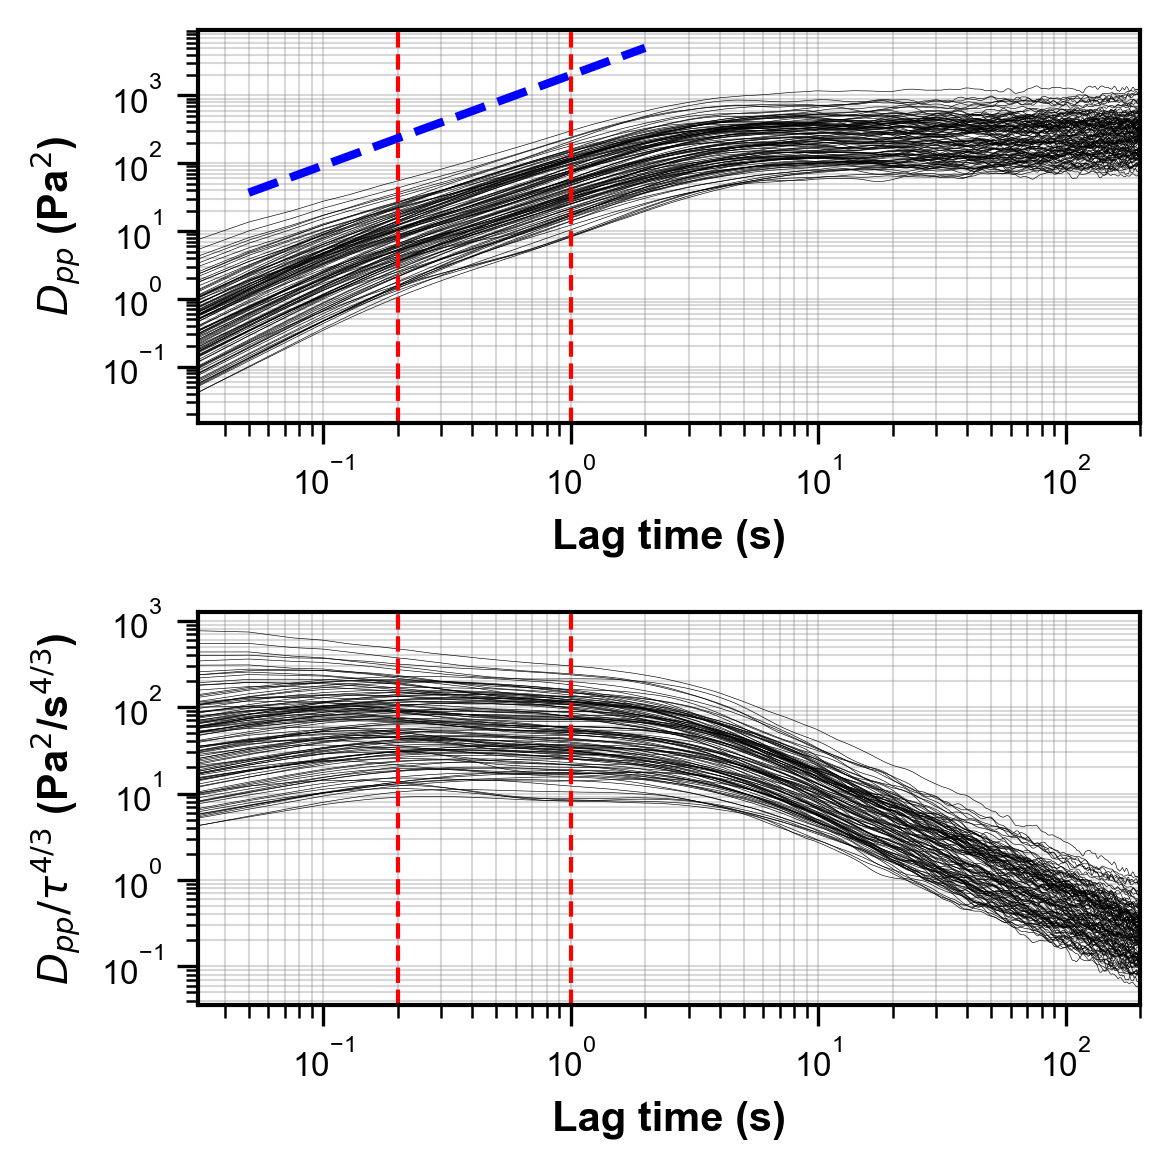

In [11]:
### Inertial subrange: Pressure structure function ###

# Inertial subrange
tau_min, tau_max = 0.2, 1

tau = Dpp['tau']
epsilonD_p = []
sigma_epsD_p = []

fig, axes = plt.subplots(2, 1, figsize=(4, 4))
for i in range(len(Cpp['t_hr'])):
    Dpp_ = Dpp['Dpp'][i]
    # U10 = ws_model[i]
    U10 = np.sqrt(Cpp['p_rms'][i])/6*25
    Uc = U10 * U_fac
    if U10 > 10:
        axes[0].loglog(tau, Dpp_, 'k-', lw=0.15)
        axes[1].loglog(tau, Dpp_/tau**(4/3), 'k-', lw=0.15)

    # Restrict to inertial subrange
    mask = (tau >= tau_min) & (tau <= tau_max)
    tau_fit, Dpp_fit = tau[mask], Dpp_[mask]

    # Estimate dissipation rate
    popt, pcov = curve_fit(lambda f, log_eps: modelD_log_p(f, log_eps, Uc), tau_fit, np.log(Dpp_fit), p0=[1e-1])
    epsilonD_p.append(np.exp(popt[0]))

    # Uncertainty estimation
    I = (Dpp_/tau**(4/3))[mask]
    sigma_epsD_p.append(0.75 * np.std(I) / np.mean(I))

epsilonD_p = np.array(epsilonD_p)
sigma_epsD_p = np.array(sigma_epsD_p)

# Remove data point influenced by earthquake
mask = (t_prs > datetime(2012, 8, 30, 12, 0)) & (epsilonD_p > 0.2)
ind_ = np.where(mask)[0]
epsilonD_p[ind_] = np.nan

axes[0].set_xlabel('Lag time (s)')
axes[0].set_ylabel(r'$D_{pp}$ (Pa$^2$)')
axes[0].set_xlim([1/32, 200])
axes[0].axvline(x=tau_min, color='r', ls='--', lw=1)
axes[0].axvline(x=tau_max, color='r', ls='--', lw=1)
axes[1].set_xlabel('Lag time (s)')
axes[1].set_ylabel(r'$D_{pp}/\tau^{4/3}$ (Pa$^2$/s$^{4/3}$)')
axes[1].set_xlim([1/32, 200])
axes[1].axvline(x=tau_min, color='r', ls='--', lw=1)
axes[1].axvline(x=tau_max, color='r', ls='--', lw=1)

# Reference scaling
tau_ = np.linspace(5e-2, 2, 100)
axes[0].loglog(tau_, 2e3*tau_**(4/3), 'b--', lw=2.0)

for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.3)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'Dpp.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Dissipation rate

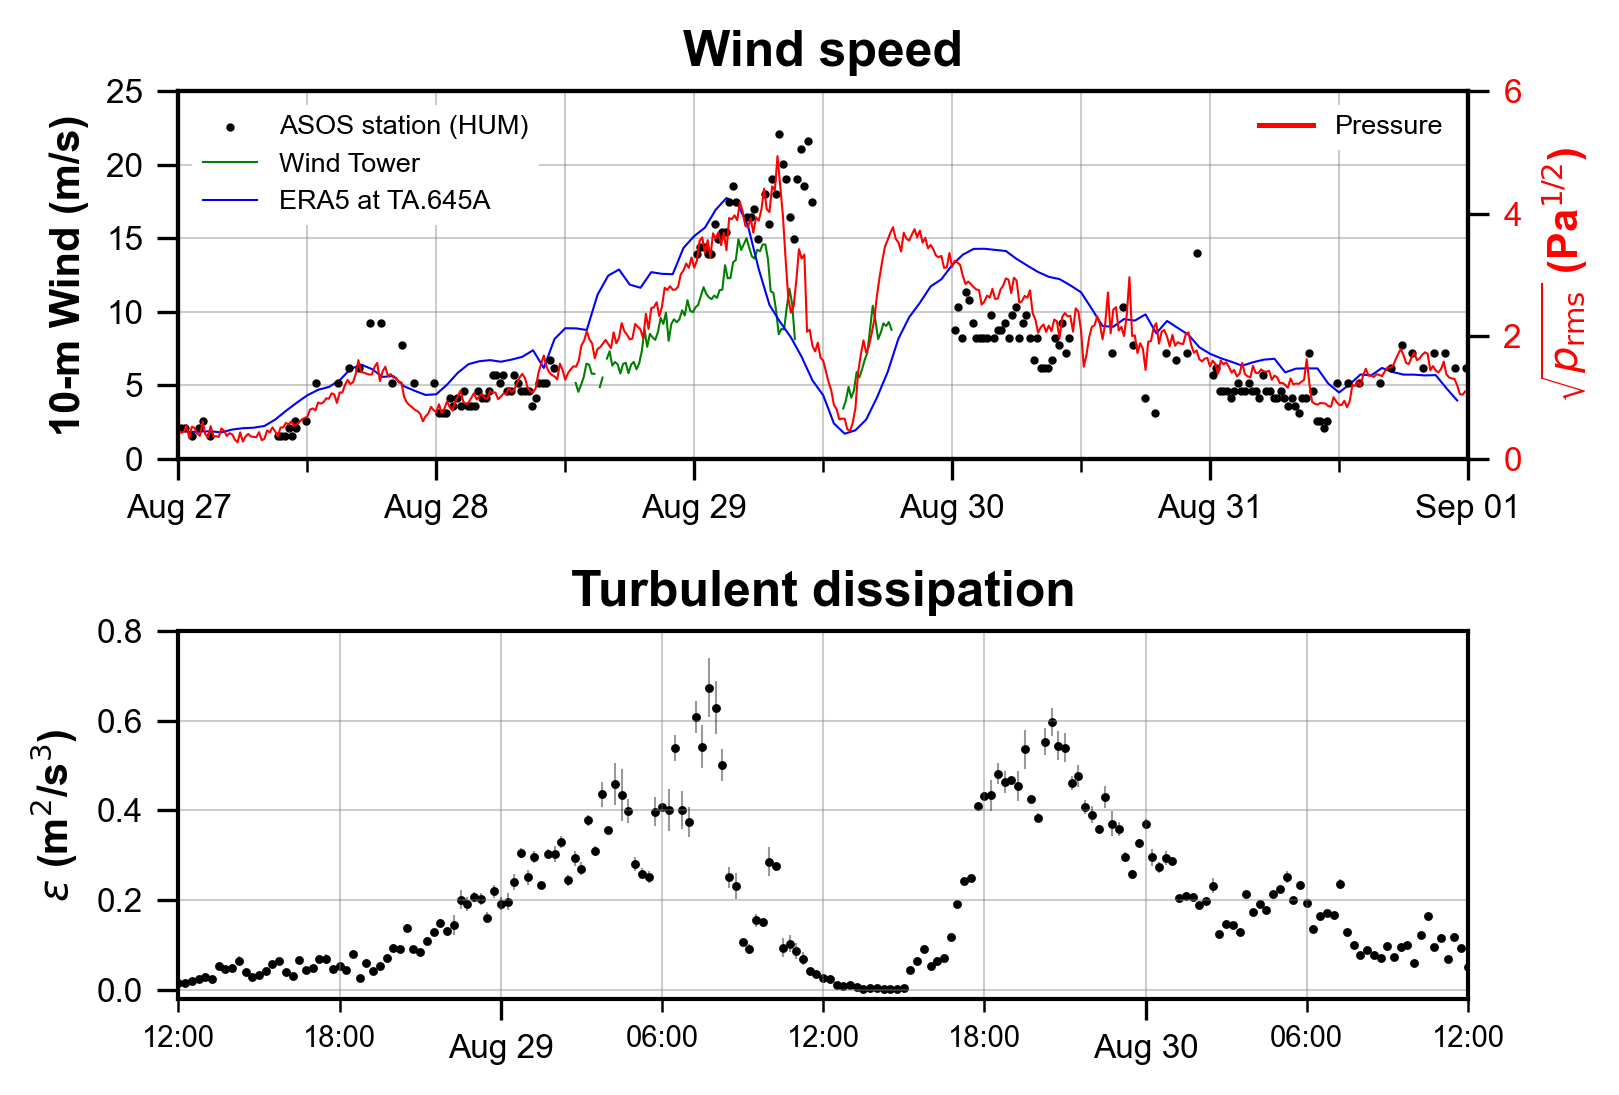

In [ ]:
### Plot dissipation rate ###

# Reliable portion
mask = (t_prs > datetime(2012,8,28,0,0)) & (t_prs < datetime(2012,8,31,12,0))
U10 = np.sqrt(Cpp['p_rms'])/6*25
# mask = (U10 > 5)

# Plot wind speed
fig, axes = plt.subplots(2, 1, figsize=(5.5, 3.75))
axes[0].scatter(asos_val['time'], asos_val['wind'], s=1, marker='o', color='k', label='ASOS station (HUM)', zorder=10)
axes[0].plot(seg_t[0], seg_U[0], 'g', lw=0.5, label='Wind Tower', zorder=11)
axes[0].plot(era5_slev_seis['valid_time'], era5_slev_seis['wspd'].values, 'b-', lw=0.5, label='ERA5 at TA.645A', zorder=9)
for tseg, useg in zip(seg_t[1:], seg_U[1:]):
    axes[0].plot(tseg, useg, 'g', lw=0.5)
# axes[0].plot(t_prs, ws_model, 'k--', lw=1, label='Fit Model')
axes[0].set_ylabel('10-m Wind (m/s)')

# Plot pressure amplitude
ax2 = axes[0].twinx()
ax2.plot(t_prs_mpl, np.sqrt(Cpp['p_rms']), lw=0.5, color='r', label='Pressure')
ax2.set_ylabel(r'$\sqrt{p_{\mathrm{rms}}}$ (Pa$^{1/2}$)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
axes[0].legend(fontsize=6.5, loc='upper left', edgecolor='none')
axes[0].set_title('Wind speed')
obj = ax2.legend(fontsize=6.5, loc='upper right', edgecolor='none')
for line in obj.get_lines():
    line.set_linewidth(1.2)

axes[0].set_xlim([t1, t2])
axes[0].set_ylim([0, 25])
ax2.set_ylim([0, 6])
axes[0].xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[0].tick_params(bottom=True, labelbottom=True)

# Plot dissipation rate
axes[1].scatter(t_prs_mpl[mask], epsilonD_p[mask], c='k', marker='.', s=5, label='Pressure estimates')
axes[1].scatter(t_prs_mpl[~mask], epsilonD_p[~mask], c='k', marker='.', s=1, alpha=0.25)
axes[1].errorbar(t_prs_mpl, epsilonD_p, yerr=sigma_epsD_p*epsilonD_p, fmt='none', ecolor='k',
                 elinewidth=0.5, alpha=0.4, capsize=0, zorder=10)

axes[1].set_ylim([-0.02, 0.8])
axes[1].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$)')
# axes[1].set_yscale('log')
axes[1].set_xlim([datetime(2012,8,28,12), datetime(2012,8,30,12)])
axes[1].set_title('Turbulent dissipation')
for ax in axes:
    ax.grid(which='both', linestyle='-', alpha=0.4)

# Date ticks
axes[0].set_xlim([t1.matplotlib_date, t2.matplotlib_date])
axes[0].xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

from matplotlib.ticker import FuncFormatter
axes[1].xaxis.set_major_locator(mdates.HourLocator(byhour=0))
axes[1].xaxis.set_minor_locator(mdates.HourLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
def minor_time_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return '' if dt.hour == 0 else dt.strftime('%H:%M')
axes[1].xaxis.set_minor_formatter(FuncFormatter(minor_time_fmt))
axes[1].tick_params(axis='x', which='minor', labelsize=7)

plt.tight_layout()
# fig.savefig(os.path.join(fig_dir, 'wind_eps.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

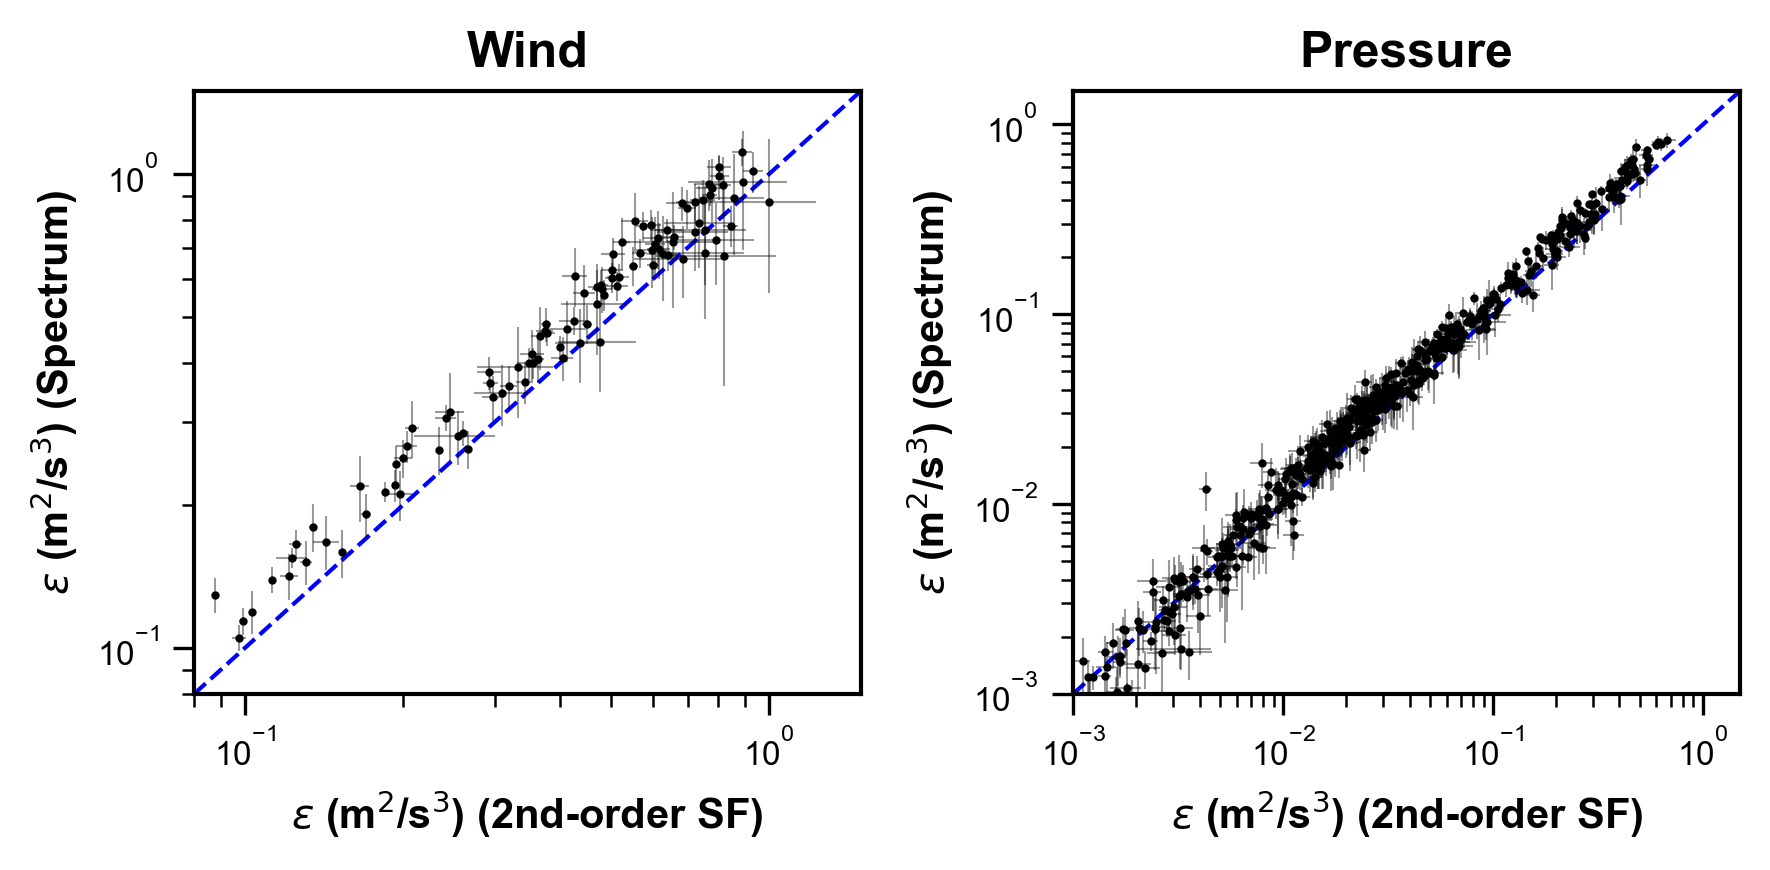

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
x1, x2 = 8e-2, 1.5
axes[0].loglog([x1, x2], [x1, x2], 'b--')
axes[0].scatter(epsilonD_u, epsilon_u, c='k', marker='.', s=4, zorder=11)
axes[0].errorbar(epsilonD_u, epsilon_u, xerr=sigma_epsD_u*epsilonD_u, yerr=sigma_eps_u*epsilon_u, fmt='none', ecolor='k',
                 elinewidth=0.5, alpha=0.4, capsize=0, zorder=10)
axes[0].set_xlim([x1, x2])
axes[0].set_ylim([x1, x2])
axes[0].set_title('Wind')
axes[0].set_xlabel(r'$\epsilon$ (m$^2$/s$^3$) (2nd-order SF)')
axes[0].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$) (Spectrum)')

x1, x2 = 1e-3, 1.5
axes[1].loglog([x1, x2], [x1, x2], 'b--')
axes[1].scatter(epsilonD_p, epsilon_p, c='k', marker='.', s=4, zorder=11)
axes[1].errorbar(epsilonD_p, epsilon_p, xerr=sigma_epsD_p*epsilonD_p, yerr=sigma_eps_p*epsilon_p, fmt='none', ecolor='k',
                 elinewidth=0.5, alpha=0.4, capsize=0, zorder=10)
axes[1].set_xlim([x1, x2])
axes[1].set_ylim([x1, x2])
axes[1].set_title('Pressure')
axes[1].set_xlabel(r'$\epsilon$ (m$^2$/s$^3$) (2nd-order SF)')
axes[1].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$) (Spectrum)')

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'compare_eps.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

a = 5.173e-03, b = 1.865, R² = 0.853
a = 2.218e-05, b = 2.910, R² = 0.764


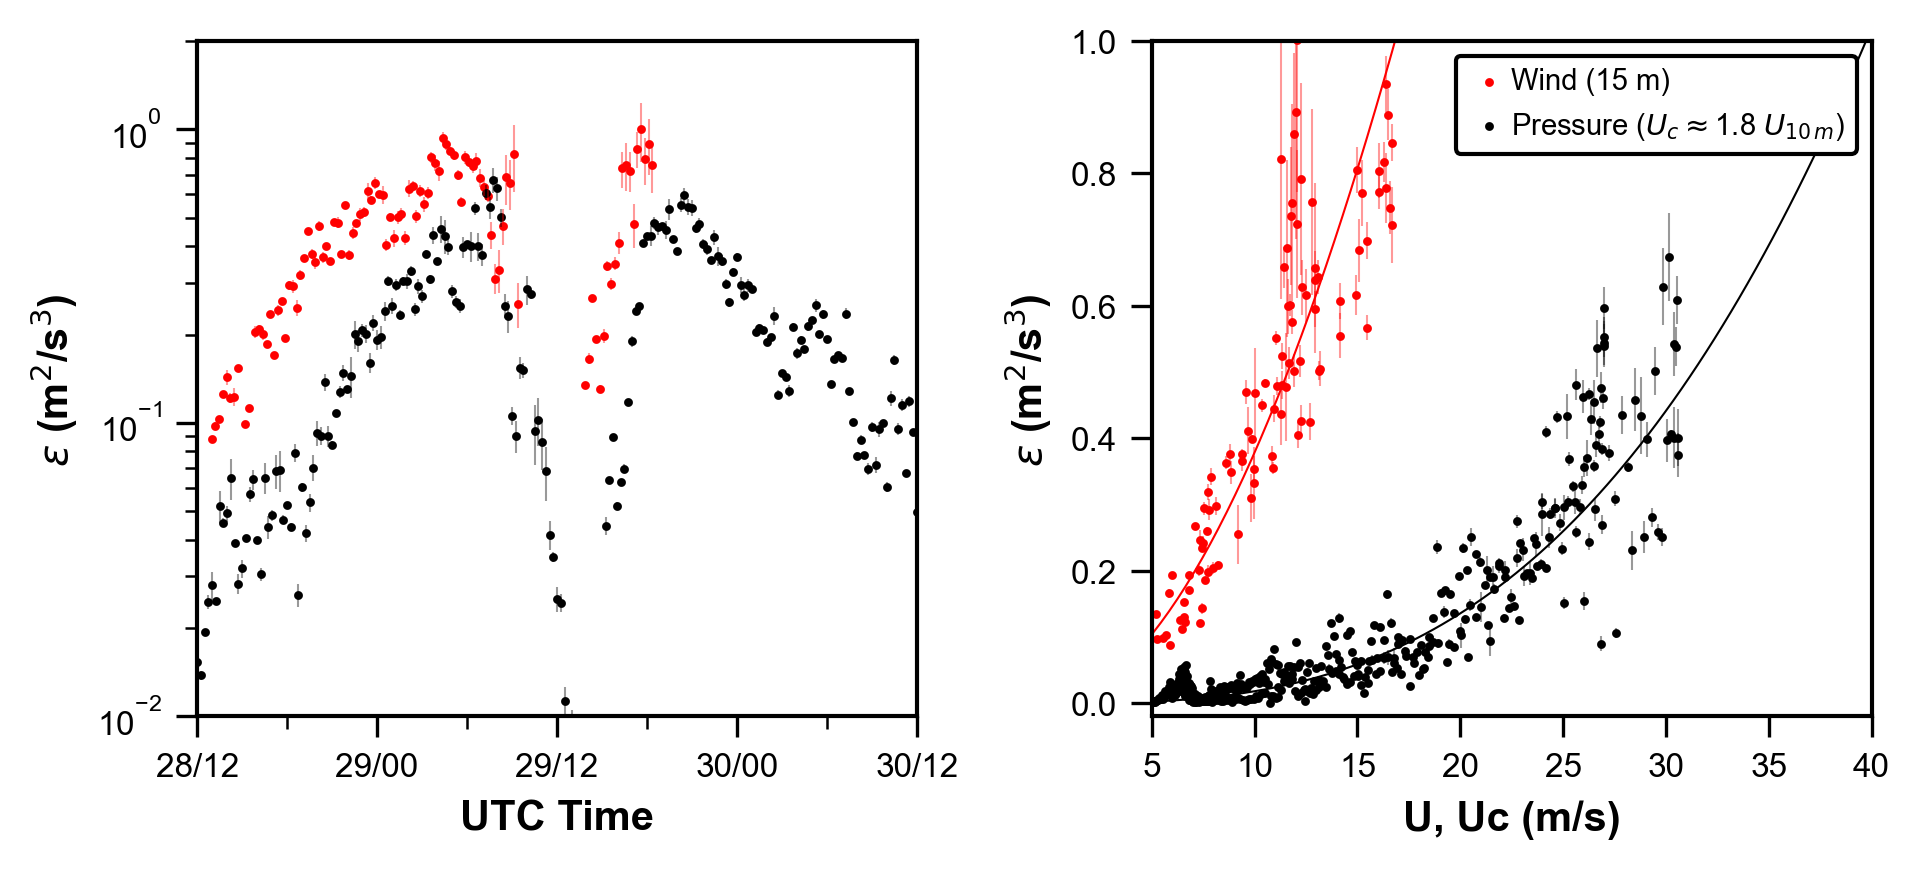

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3))

axes[0].scatter(Duu['time'], epsilonD_u, c='r', marker='.', s=5)
axes[0].scatter(t_prs_mpl, epsilonD_p, c='k', marker='.', s=5)
axes[0].errorbar(Duu['time'], epsilonD_u, yerr=sigma_epsD_u*epsilonD_u, fmt='none', ecolor='r',
                 elinewidth=0.5, alpha=0.4, capsize=0)
axes[0].errorbar(t_prs_mpl, epsilonD_p, yerr=sigma_epsD_p*epsilonD_p, fmt='none', ecolor='k',
                 elinewidth=0.5, alpha=0.4, capsize=0)
axes[0].set_yscale('log')
axes[0].set_ylim([1e-2, 1.5])
axes[0].set_ylim([1e-2, 2])
axes[0].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$)')

# Date ticks
x1, x2 = datetime(2012,8,28,12,0), datetime(2012,8,30,12,0)
# x1, x2 = datetime(2012,8,28,0,0), datetime(2012,8,31,0,0)
axes[0].set_xlim([x1, x2])
axes[0].set_xlabel('UTC Time')
axes[0].xaxis.set_major_locator(mdates.HourLocator(byhour=range(0,24,12)))
axes[0].xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0,24,6)))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%H'))

# mask = (ws_model*U_fac > 10)
mask = (ws_model*U_fac > 5)
axes[1].scatter(Duu['U'], epsilonD_u, c='r', marker='.', s=5)
axes[1].scatter(ws_model[mask]*U_fac, epsilonD_p[mask], c='k', marker='.', s=5)
axes[1].errorbar(Duu['U'], epsilonD_u, yerr=sigma_epsD_u*epsilonD_u, fmt='none', ecolor='r',
                 elinewidth=0.5, alpha=0.4, capsize=0)
axes[1].errorbar(ws_model[mask]*U_fac, epsilonD_p[mask], yerr=sigma_epsD_p[mask]*epsilonD_p[mask], fmt='none', ecolor='k',
                 elinewidth=0.5, alpha=0.4, capsize=0)
axes[1].set_xlim([4, 32])
axes[1].set_ylim([-0.02, 1.2])
axes[1].set_xlim([5, 40])
axes[1].set_ylim([-0.02, 1])
axes[1].set_xlabel('U, Uc (m/s)')
axes[1].set_ylabel(r'$\epsilon$ (m$^2$/s$^3$)')
axes[1].legend(['Wind (15 m)', rf'Pressure ($U_{{c}}$$\approx${U_fac} $U_{{10\,m}}$)'], 
               fontsize=7, loc='upper right', handletextpad=0, handlelength=1.5)

# Power law
from scipy.stats import linregress

U_fit = Duu['U']
eps_fit = epsilonD_u
slope, intercept, r_value, _, _ = linregress(np.log10(U_fit), np.log10(eps_fit))
a, b = 10**intercept, slope
print(f"a = {a:.3e}, b = {b:.3f}, R² = {r_value**2:.3f}")
u_ = np.linspace(0, 40, 200)
axes[1].plot(u_, a * u_**b, 'r-', lw=0.5)

U_fit = ws_model[mask] * U_fac
eps_fit = epsilonD_p[mask]
valid = np.isfinite(eps_fit) & (U_fit > 10)
slope, intercept, r_value, _, _ = linregress(np.log10(U_fit[valid]), np.log10(eps_fit[valid]))
a, b = 10**intercept, slope
print(f"a = {a:.3e}, b = {b:.3f}, R² = {r_value**2:.3f}")
axes[1].plot(u_, a * u_**b, 'k-', lw=0.5)

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'eps_U.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Statistics of uncertainty

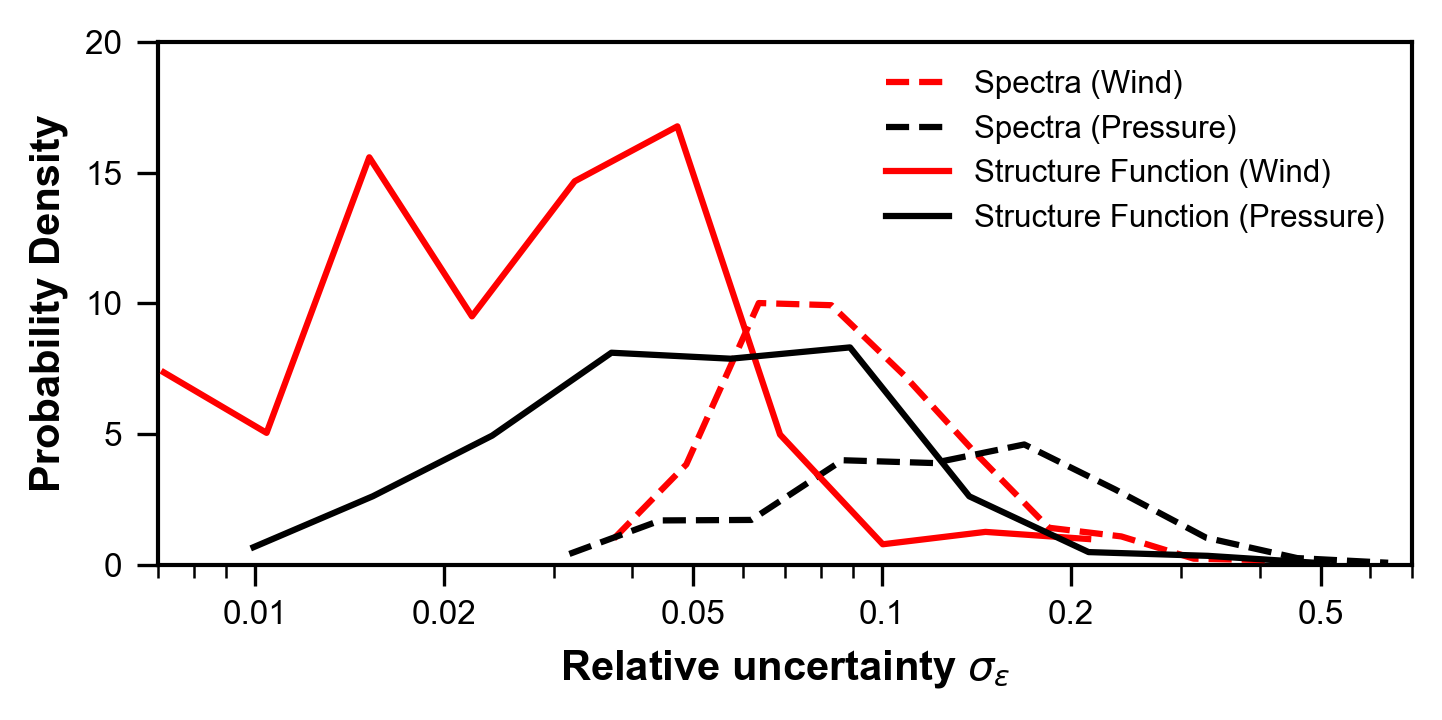

In [ ]:
import matplotlib.ticker as mticker

# PDF bins in log space
def pdf_bins(x, nbins, scale='log'):
    x = np.asarray(x)
    x = x[np.isfinite(x) & (x > 0)]
    if scale == 'log':
        bins = np.logspace(np.log10(x.min()), np.log10(x.max()), nbins + 1)
    elif scale == 'linear':
        bins = np.linspace(x.min(), x.max(), nbins + 1)

    counts, edges = np.histogram(x, bins=bins)
    # widths = np.diff(np.log10(edges))
    widths = np.diff(edges)

    pdf = counts / counts.sum() / widths
    if scale == 'log':
        centers = 10**(0.5 * (np.log10(edges[:-1]) + np.log10(edges[1:])))
    elif scale == 'linear':
        centers = 0.5 * (edges[:-1] + edges[1:])

    return centers, pdf

# Calculate PDFs
scale = 'log'
nbins = 10
xc_u,  pdf_u  = pdf_bins(sigma_eps_u,  nbins=nbins, scale=scale)
xc_D,  pdf_D  = pdf_bins(sigma_epsD_u, nbins=nbins, scale=scale)
xc_up, pdf_up = pdf_bins(sigma_eps_p,  nbins=nbins, scale=scale)
xc_Dp, pdf_Dp = pdf_bins(sigma_epsD_p, nbins=nbins, scale=scale)

# Plot PDFs
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(xc_u, pdf_u, lw=1.5, ls='--', color="r",
        label="Spectra (Wind)", zorder=10)
ax.plot(xc_up, pdf_up, lw=1.5, ls="--", color="k",
        label="Spectra (Pressure)", zorder=10)
ax.plot(xc_D, pdf_D, lw=1.5, ls="-", color="r",
        label="Structure Function (Wind)", zorder=11)
ax.plot(xc_Dp, pdf_Dp, lw=1.5, ls="-", color="k",
        label="Structure Function (Pressure)", zorder=11)

ax.set_xscale(scale)
ax.set_xlim(0.007, 0.7)
ax.set_ylim(0, 20)

ax.set_xlabel(r"Relative uncertainty $\sigma_\epsilon$")
ax.set_ylabel("Probability Density")

ax.tick_params(which="both")
ax.legend(frameon=False, fontsize=7.5)
ax.xaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))

plt.tight_layout()
# fig.savefig(os.path.join(sup_dir, 'sigma_eps.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)
